# Data Importing

In [6]:
!pip install kaggle -q

In [1]:
import os
import zipfile
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [47]:
from pathlib import Path

token = "KGAT_d69bff3fea7b5c23cc7c0ce36c850901"

Path("/root/.kaggle").mkdir(parents=True, exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(token)

os.chmod("/root/.kaggle/access_token", 0o600)

In [9]:
!mkdir -p /content/startup_data

!kaggle datasets download \
  -d yanmaksi/big-startup-secsees-fail-dataset-from-crunchbase \
  -p /content/startup_data \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/yanmaksi/big-startup-secsees-fail-dataset-from-crunchbase
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 2.82M/2.82M [00:00<00:00, 91.7MB/s]



In [10]:
for root, dirs, files in os.walk("/content/startup_data"):
    for file in files:
        print(os.path.join(root, file))

/content/startup_data/big_startup_secsees_dataset.csv


In [11]:
csv_files = glob.glob("/content/startup_data/**/*.csv", recursive=True)
csv_files

['/content/startup_data/big_startup_secsees_dataset.csv']

In [48]:
df = pd.read_csv(csv_files[0])


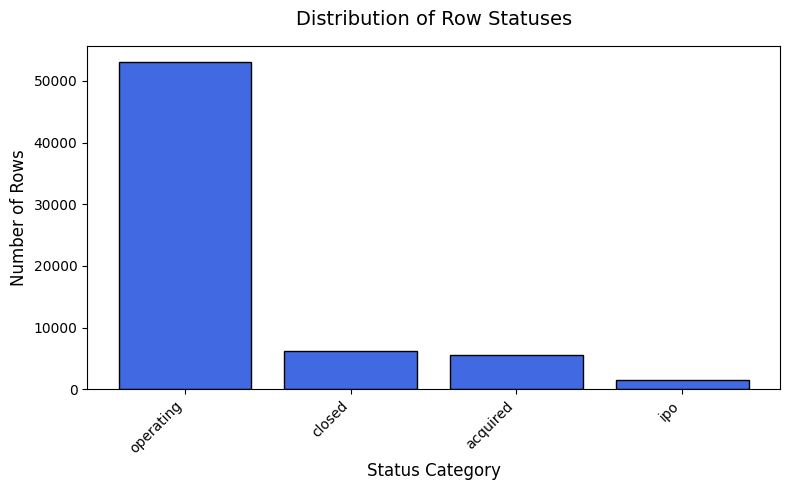

In [13]:
status_counts = df["status"].value_counts()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(status_counts.index, status_counts.values, color="royalblue", edgecolor="black")

ax.set_title("Distribution of Row Statuses", fontsize=14, pad=15)
ax.set_xlabel("Status Category", fontsize=12)
ax.set_ylabel("Number of Rows", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()


# Success / failure

In [56]:
df = df.copy()

success_statuses = ["acquired", "ipo"]
failure_statuses = ["closed"]

df = df[df["status"].isin(success_statuses + failure_statuses)].copy()

df["target"] = df["status"].isin(success_statuses).astype(int)

df["target"].value_counts(normalize=True)



,proportion
target,
1,0.532173
0,0.467827


In [62]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list',
       'funding_total_usd', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'first_funding_at',
       'last_funding_at', 'target'],
      dtype='object')

In [63]:
df.head(3)

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,target
15,/organization/1-mainstream,1 Mainstream,http://www.1mainstream.com,Apps|Cable|Distribution|Software,5000000,acquired,USA,CA,SF Bay Area,Cupertino,1,2012-03-01,2015-03-17,2015-03-17,1
20,/organization/1000-markets,1000 Markets,http://www.1000markets.com,Art|E-Commerce|Marketplaces,500000,acquired,USA,WA,Seattle,Seattle,1,2009-01-01,2009-05-15,2009-05-15,1
23,/organization/1000memories,1000memories,http://1000memories.com,Curated Web,2535000,acquired,USA,CA,SF Bay Area,San Francisco,2,2010-07-01,2010-01-01,2011-02-16,1


# Feature engineering

In [147]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [139]:
target_col = "target"

model_df = df[df[target_col].notna()].copy()
model_df[target_col] = model_df[target_col].astype(int)

print(model_df.shape)
print(model_df[target_col].value_counts())
print(model_df[target_col].value_counts(normalize=True))

(13334, 29)
target
1    7096
0    6238
Name: count, dtype: int64
target
1    0.532173
0    0.467827
Name: proportion, dtype: float64


In [140]:
train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=42,
    stratify=model_df[target_col]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df[target_col]
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (9333, 29)
Val: (2000, 29)
Test: (2001, 29)


# Category Encoding

In [141]:
def fit_category_encoder(train_df, top_n_categories=100):
    category_clean = (
        train_df["category_list"]
        .fillna("Unknown")
        .astype(str)
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    category_dummies = category_clean.str.get_dummies(sep="|")
    category_counts = category_dummies.sum().sort_values(ascending=False)

    top_categories = category_counts.head(top_n_categories).index.tolist()

    return top_categories


def transform_categories(df_part, top_categories):
    category_clean = (
        df_part["category_list"]
        .fillna("Unknown")
        .astype(str)
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    category_dummies = category_clean.str.get_dummies(sep="|")

    category_features = pd.DataFrame(index=df_part.index)

    for cat in top_categories:
        if cat in category_dummies.columns:
            category_features[cat] = category_dummies[cat]
        else:
            category_features[cat] = 0

    non_top_cols = [
        col for col in category_dummies.columns
        if col not in top_categories
    ]

    if len(non_top_cols) > 0:
        category_features["other_category"] = (
            category_dummies[non_top_cols].sum(axis=1) > 0
        ).astype(int)
    else:
        category_features["other_category"] = 0

    return category_features

In [142]:
top_categories = fit_category_encoder(train_df, top_n_categories=100)

train_category_features = transform_categories(train_df, top_categories)
val_category_features = transform_categories(val_df, top_categories)
test_category_features = transform_categories(test_df, top_categories)

print(train_category_features.shape)
print(val_category_features.shape)
print(test_category_features.shape)

/tmp/ipykernel_16578/3805840839.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  category_features["other_category"] = (
/tmp/ipykernel_16578/3805840839.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  category_features["other_category"] = (


(9333, 101)
(2000, 101)
(2001, 101)


/tmp/ipykernel_16578/3805840839.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  category_features["other_category"] = (


# Location Encoding

In [143]:
def fit_top_values(train_df, col, k):
    return (
        train_df[col]
        .fillna("Unknown")
        .astype(str)
        .value_counts()
        .head(k)
        .index
        .tolist()
    )


def apply_top_or_other(series, top_values):
    series = series.fillna("Unknown").astype(str)
    return series.where(series.isin(top_values), other="Other")


def fit_location_encoder(train_df):
    top_values = {
        "country_code": fit_top_values(train_df, "country_code", 50),
        "state_code": fit_top_values(train_df, "state_code", 80),
        "region": fit_top_values(train_df, "region", 100),
    }

    train_limited = pd.DataFrame(index=train_df.index)

    for col, values in top_values.items():
        train_limited[col + "_limited"] = apply_top_or_other(
            train_df[col],
            values
        )

    location_columns = pd.get_dummies(
        train_limited,
        drop_first=False
    ).columns.tolist()

    return top_values, location_columns


def transform_locations(df_part, top_values, location_columns):
    limited = pd.DataFrame(index=df_part.index)

    for col, values in top_values.items():
        limited[col + "_limited"] = apply_top_or_other(
            df_part[col],
            values
        )

    features = pd.get_dummies(limited, drop_first=False)

    features = features.reindex(columns=location_columns, fill_value=0)

    return features

In [144]:
top_location_values, location_columns = fit_location_encoder(train_df)

train_location_features = transform_locations(
    train_df,
    top_location_values,
    location_columns
)

val_location_features = transform_locations(
    val_df,
    top_location_values,
    location_columns
)

test_location_features = transform_locations(
    test_df,
    top_location_values,
    location_columns
)

print(train_location_features.shape)
print(val_location_features.shape)
print(test_location_features.shape)

(9333, 233)
(2000, 233)
(2001, 233)


# Numeric Encoding

In [145]:
def create_numeric_features(df_part, observation_window_days=365):
    df_part = df_part.copy()

    df_part["founded_at"] = pd.to_datetime(
        df_part["founded_at"],
        errors="coerce"
    )

    df_part["first_funding_at"] = pd.to_datetime(
        df_part["first_funding_at"],
        errors="coerce"
    )

    df_part["prediction_cutoff_date"] = (
        df_part["founded_at"] + pd.to_timedelta(
            observation_window_days,
            unit="D"
        )
    )

    df_part["has_homepage"] = df_part["homepage_url"].notna().astype(int)

    df_part["first_funding_within_window"] = (
        df_part["first_funding_at"].notna()
        & df_part["founded_at"].notna()
        & (df_part["first_funding_at"] >= df_part["founded_at"])
        & (df_part["first_funding_at"] <= df_part["prediction_cutoff_date"])
    ).astype(int)

    df_part["days_to_first_funding_within_window"] = np.where(
        df_part["first_funding_within_window"] == 1,
        (df_part["first_funding_at"] - df_part["founded_at"]).dt.days,
        np.nan
    )

    df_part["years_to_first_funding_within_window"] = (
        df_part["days_to_first_funding_within_window"] / 365.25
    )

    df_part["first_funding_not_observed_in_window"] = (
        df_part["first_funding_within_window"] == 0
    ).astype(int)

    df_part["years_to_first_funding_within_window"] = (
        df_part["years_to_first_funding_within_window"].fillna(0)
    )

    df_part["log_years_to_first_funding_within_window"] = np.log1p(
        df_part["years_to_first_funding_within_window"]
    )

    df_part["founded_year"] = df_part["founded_at"].dt.year
    df_part["founded_year_missing"] = df_part["founded_year"].isna().astype(int)

    numeric_features = df_part[[
        "log_years_to_first_funding_within_window",
        "first_funding_within_window",
        "first_funding_not_observed_in_window",
        "has_homepage",
        "founded_year",
        "founded_year_missing"
    ]].copy()

    return numeric_features

In [146]:
train_numeric_features = create_numeric_features(train_df)
val_numeric_features = create_numeric_features(val_df)
test_numeric_features = create_numeric_features(test_df)

print(train_numeric_features.shape)
print(val_numeric_features.shape)
print(test_numeric_features.shape)

(9333, 6)
(2000, 6)
(2001, 6)


## Filling Missing Founded Year

In [148]:
founded_year_median = train_numeric_features["founded_year"].median()

train_numeric_features["founded_year"] = train_numeric_features["founded_year"].fillna(
    founded_year_median
)

val_numeric_features["founded_year"] = val_numeric_features["founded_year"].fillna(
    founded_year_median
)

test_numeric_features["founded_year"] = test_numeric_features["founded_year"].fillna(
    founded_year_median
)

In [149]:
continuous_cols = [
    "log_years_to_first_funding_within_window",
    "founded_year"
]

scaler = StandardScaler()

train_numeric_features[continuous_cols] = scaler.fit_transform(
    train_numeric_features[continuous_cols]
)

val_numeric_features[continuous_cols] = scaler.transform(
    val_numeric_features[continuous_cols]
)

test_numeric_features[continuous_cols] = scaler.transform(
    test_numeric_features[continuous_cols]
)

# Matrix Construction

In [151]:
X_train = pd.concat(
    [
        train_numeric_features.reset_index(drop=True),
        train_category_features.reset_index(drop=True),
        train_location_features.reset_index(drop=True)
    ],
    axis=1
)

X_val = pd.concat(
    [
        val_numeric_features.reset_index(drop=True),
        val_category_features.reset_index(drop=True),
        val_location_features.reset_index(drop=True)
    ],
    axis=1
)

X_test = pd.concat(
    [
        test_numeric_features.reset_index(drop=True),
        test_category_features.reset_index(drop=True),
        test_location_features.reset_index(drop=True)
    ],
    axis=1
)

y_train = train_df[target_col].astype(np.float32).reset_index(drop=True)
y_val = val_df[target_col].astype(np.float32).reset_index(drop=True)
y_test = test_df[target_col].astype(np.float32).reset_index(drop=True)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

In [152]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\nDtypes:")
print(X_train.dtypes.value_counts())

print("\nTarget balance:")
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

X_train: (9333, 340)
X_val: (2000, 340)
X_test: (2001, 340)
y_train: (9333,)
y_val: (2000,)
y_test: (2001,)

Dtypes:
float32    340
Name: count, dtype: int64

Target balance:
target
1.0    0.532198
0.0    0.467802
Name: proportion, dtype: float64
target
1.0    0.532
0.0    0.468
Name: proportion, dtype: float64
target
1.0    0.532234
0.0    0.467766
Name: proportion, dtype: float64


# PyTorch Dataset

In [153]:
class StartupDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [154]:
train_dataset = StartupDataset(X_train, y_train)
val_dataset = StartupDataset(X_val, y_val)
test_dataset = StartupDataset(X_test, y_test)

In [155]:
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Pytorch Model

In [156]:
class StartupMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [157]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [158]:
input_dim = X_train.shape[1]

model = StartupMLP(input_dim).to(device)

In [159]:
criterion = nn.BCEWithLogitsLoss()

In [160]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Training Loop

In [161]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

## Validation Function

In [164]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            total_loss += loss.item() * X_batch.size(0)

            all_probs.extend(probs.cpu().numpy().flatten())
            all_targets.extend(y_batch.cpu().numpy().flatten())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    preds = (all_probs >= 0.5).astype(int)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_targets, preds),
        "precision": precision_score(all_targets, preds, zero_division=0),
        "recall": recall_score(all_targets, preds, zero_division=0),
        "f1": f1_score(all_targets, preds, zero_division=0),
        "roc_auc": roc_auc_score(all_targets, all_probs)
    }

    return metrics

## Train

In [166]:
num_epochs = 40

best_val_f1 = 0
best_model_state = None

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_metrics = evaluate(model, val_loader, criterion)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC: {val_metrics['roc_auc']:.4f}"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_model_state = model.state_dict()

Epoch 01 | Train Loss: 0.2862 | Val Loss: 0.7981 | Val F1: 0.6962 | Val ROC-AUC: 0.7426
Epoch 02 | Train Loss: 0.2776 | Val Loss: 0.8157 | Val F1: 0.7050 | Val ROC-AUC: 0.7473
Epoch 03 | Train Loss: 0.2719 | Val Loss: 0.8409 | Val F1: 0.6944 | Val ROC-AUC: 0.7515
Epoch 04 | Train Loss: 0.2763 | Val Loss: 0.8431 | Val F1: 0.7115 | Val ROC-AUC: 0.7547
Epoch 05 | Train Loss: 0.2636 | Val Loss: 0.8527 | Val F1: 0.7000 | Val ROC-AUC: 0.7446
Epoch 06 | Train Loss: 0.2655 | Val Loss: 0.8660 | Val F1: 0.7005 | Val ROC-AUC: 0.7443
Epoch 07 | Train Loss: 0.2563 | Val Loss: 0.8756 | Val F1: 0.6992 | Val ROC-AUC: 0.7382
Epoch 08 | Train Loss: 0.2518 | Val Loss: 0.8908 | Val F1: 0.6979 | Val ROC-AUC: 0.7427
Epoch 09 | Train Loss: 0.2526 | Val Loss: 0.9138 | Val F1: 0.6943 | Val ROC-AUC: 0.7431
Epoch 10 | Train Loss: 0.2539 | Val Loss: 0.8934 | Val F1: 0.7108 | Val ROC-AUC: 0.7469
Epoch 11 | Train Loss: 0.2485 | Val Loss: 0.9262 | Val F1: 0.7094 | Val ROC-AUC: 0.7492
Epoch 12 | Train Loss: 0.2428 | 

In [41]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

# Evaluate on Test Set

In [167]:
test_metrics = evaluate(model, test_loader, criterion)
test_metrics

{'loss': 1.2615014772186395,
 'accuracy': 0.665167416291854,
 'precision': 0.6868495742667928,
 'recall': 0.6816901408450704,
 'f1': 0.6842601319509897,
 'roc_auc': np.float64(0.7077148790176958)}

In [168]:
model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy().flatten())
        all_targets.extend(y_batch.numpy().flatten())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

all_preds = (all_probs >= 0.5).astype(int)

print(classification_report(all_targets, all_preds))
print(confusion_matrix(all_targets, all_preds))

              precision    recall  f1-score   support

         0.0       0.64      0.65      0.64       936
         1.0       0.69      0.68      0.68      1065

    accuracy                           0.67      2001
   macro avg       0.66      0.66      0.66      2001
weighted avg       0.67      0.67      0.67      2001

[[605 331]
 [339 726]]


In [170]:
thresholds = np.linspace(0.1, 0.9, 81)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    f1 = f1_score(all_targets, preds, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

best_threshold, best_f1

final_preds = (all_probs >= best_threshold).astype(int)

print(classification_report(all_targets, final_preds))
print(confusion_matrix(all_targets, final_preds))

              precision    recall  f1-score   support

         0.0       0.71      0.50      0.59       936
         1.0       0.65      0.82      0.73      1065

    accuracy                           0.67      2001
   macro avg       0.68      0.66      0.66      2001
weighted avg       0.68      0.67      0.66      2001

[[466 470]
 [191 874]]


# Feature Importance

In [171]:
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np
import pandas as pd
import torch

def get_model_probs(model, X_df, device):
    model.eval()

    X_tensor = torch.tensor(
        X_df.to_numpy(dtype=np.float32),
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()

    return probs

In [172]:
baseline_probs = get_model_probs(model, X_test, device)
baseline_preds = (baseline_probs >= best_threshold).astype(int)

baseline_f1 = f1_score(y_test, baseline_preds)
baseline_auc = roc_auc_score(y_test, baseline_probs)

print("Baseline F1:", baseline_f1)
print("Baseline ROC-AUC:", baseline_auc)

Baseline F1: 0.7256122872561229
Baseline ROC-AUC: 0.7077148790176958


In [173]:
def permutation_importance(model, X_test, y_test, device, threshold, metric="f1", n_repeats=5):
    results = []

    baseline_probs = get_model_probs(model, X_test, device)
    baseline_preds = (baseline_probs >= threshold).astype(int)

    if metric == "f1":
        baseline_score = f1_score(y_test, baseline_preds)
    elif metric == "roc_auc":
        baseline_score = roc_auc_score(y_test, baseline_probs)
    else:
        raise ValueError("metric must be 'f1' or 'roc_auc'")

    for col in X_test.columns:
        drops = []

        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            X_permuted[col] = np.random.permutation(X_permuted[col].values)

            permuted_probs = get_model_probs(model, X_permuted, device)
            permuted_preds = (permuted_probs >= threshold).astype(int)

            if metric == "f1":
                permuted_score = f1_score(y_test, permuted_preds)
            else:
                permuted_score = roc_auc_score(y_test, permuted_probs)

            drops.append(baseline_score - permuted_score)

        results.append({
            "feature": col,
            "importance_mean": np.mean(drops),
            "importance_std": np.std(drops)
        })

    importance_df = pd.DataFrame(results)
    importance_df = importance_df.sort_values("importance_mean", ascending=False)

    return importance_df

In [174]:
importance_df = permutation_importance(
    model=model,
    X_test=X_test,
    y_test=y_test,
    device=device,
    threshold=best_threshold,
    metric="f1",
    n_repeats=5
)

importance_df.head(30)

,feature,importance_mean,importance_std
4,founded_year,0.032699,0.003475
9,unknown,0.023240,0.001528
5,founded_year_missing,0.007936,0.002343
1,first_funding_within_window,0.006971,0.002685
334,region_limited_Unknown,0.004602,0.002052
156,country_code_limited_Unknown,0.004492,0.001181
6,software,0.004458,0.002438
3,has_homepage,0.003968,0.001266
197,state_code_limited_CA,0.003749,0.000843
314,region_limited_SF Bay Area,0.002848,0.000887


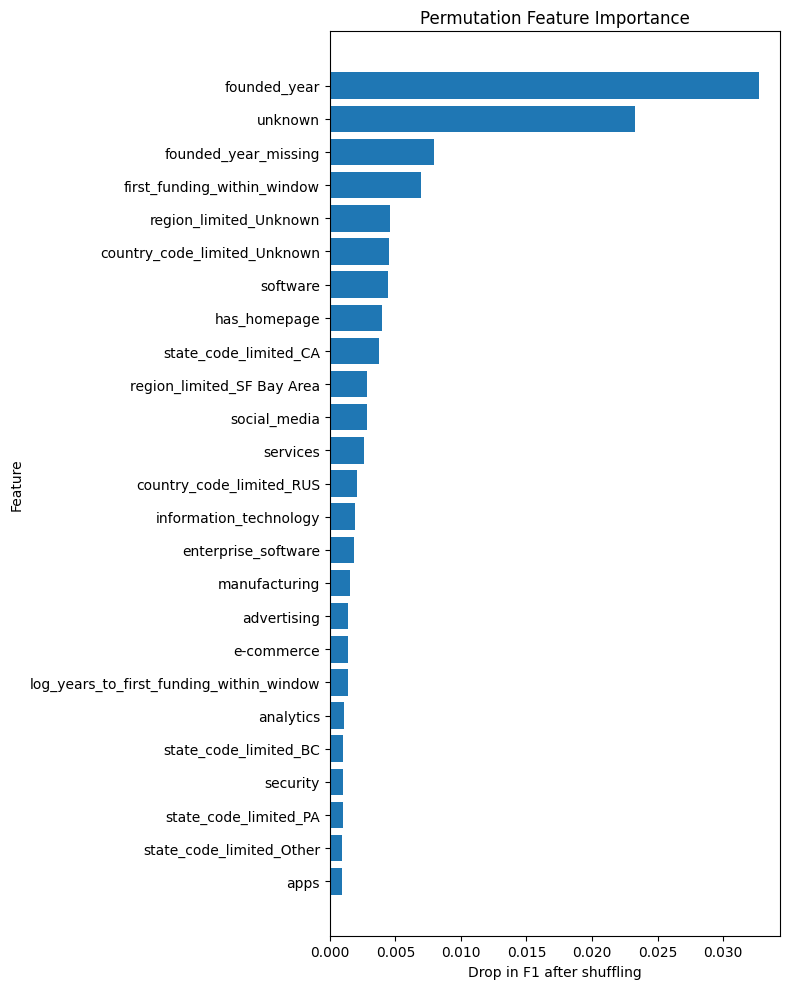

In [175]:
import matplotlib.pyplot as plt

top_n = 25
top_features = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(8, 10))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.xlabel("Drop in F1 after shuffling")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

In [176]:
numeric_cols = numeric_features.columns.tolist()
category_cols = category_features.columns.tolist()
location_cols = location_features.columns.tolist()

In [177]:
def feature_group(feature):
    if feature in numeric_cols:
        return "numeric"
    elif feature in category_cols:
        return "category"
    elif feature in location_cols:
        return "location"
    else:
        return "unknown"

importance_df["group"] = importance_df["feature"].apply(feature_group)

group_importance = (
    importance_df
    .groupby("group")["importance_mean"]
    .sum()
    .sort_values(ascending=False)
)

group_importance

,importance_mean
group,
unknown,0.049357
category,0.024155
numeric,0.003968
location,-0.011288


# Model Comparison (Logistic Regression, Random Forest and Gradient Boosting)

In [178]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

def make_pipeline(model, scale=True):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]

    if scale:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    return Pipeline(steps)

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=1000, random_state=42),
        scale=True
    ),

    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        scale=False
    ),

    "Gradient Boosting": make_pipeline(
        GradientBoostingClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        ),
        scale=False
    ),
}

In [179]:
results = {}

for name, pipe in models.items():
    print(f"Training {name}...")

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "acc": accuracy_score(y_test, y_pred),
        "prec": precision_score(y_test, y_pred),
        "rec": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
        "pipeline": pipe
    }

    print(f"\n{name}")
    print(f"Accuracy:  {results[name]['acc']:.4f}")
    print(f"Precision: {results[name]['prec']:.4f}")
    print(f"Recall:    {results[name]['rec']:.4f}")
    print(f"F1:        {results[name]['f1']:.4f}")
    print(f"ROC-AUC:   {results[name]['auc']:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

Training Logistic Regression...

Logistic Regression
Accuracy:  0.7121
Precision: 0.7060
Recall:    0.7869
F1:        0.7442
ROC-AUC:   0.7827
[[587 349]
 [227 838]]
              precision    recall  f1-score   support

         0.0       0.72      0.63      0.67       936
         1.0       0.71      0.79      0.74      1065

    accuracy                           0.71      2001
   macro avg       0.71      0.71      0.71      2001
weighted avg       0.71      0.71      0.71      2001

Training Random Forest...

Random Forest
Accuracy:  0.7086
Precision: 0.6785
Recall:    0.8601
F1:        0.7586
ROC-AUC:   0.7874
[[502 434]
 [149 916]]
              precision    recall  f1-score   support

         0.0       0.77      0.54      0.63       936
         1.0       0.68      0.86      0.76      1065

    accuracy                           0.71      2001
   macro avg       0.72      0.70      0.70      2001
weighted avg       0.72      0.71      0.70      2001

Training Gradient Boosting

In [180]:
import numpy as np

def find_best_threshold(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_t = 0.5
    best_f1 = 0

    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f1 = f1_score(y_true, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

for name, r in results.items():
    best_t, best_f1 = find_best_threshold(y_test, r["y_proba"])
    preds = (r["y_proba"] >= best_t).astype(int)

    print(f"\n{name}")
    print("Best threshold:", best_t)
    print("Best F1:", best_f1)
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))


Logistic Regression
Best threshold: 0.30999999999999994
Best F1: 0.7697111631537861
              precision    recall  f1-score   support

         0.0       0.84      0.45      0.59       936
         1.0       0.66      0.93      0.77      1065

    accuracy                           0.71      2001
   macro avg       0.75      0.69      0.68      2001
weighted avg       0.75      0.71      0.69      2001

[[425 511]
 [ 79 986]]

Random Forest
Best threshold: 0.4499999999999999
Best F1: 0.7661069894572433
              precision    recall  f1-score   support

         0.0       0.83      0.45      0.58       936
         1.0       0.66      0.92      0.77      1065

    accuracy                           0.70      2001
   macro avg       0.74      0.69      0.68      2001
weighted avg       0.74      0.70      0.68      2001

[[421 515]
 [ 84 981]]

Gradient Boosting
Best threshold: 0.37999999999999995
Best F1: 0.7734806629834254
              precision    recall  f1-score   support
